In [155]:
from joblib import Parallel, delayed
import os
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
pd.set_option('display.max_rows', 200)
pd.get_option('display.max_columns', 30) 

20

In [156]:
# dictionary = "D:\\guojun\\okxapi\\crypto_futures_data\\selfdump\\event_modified\\"
# files = os.listdir(dictionary)
# res = []
# for file in files:
#     df = pd.read_parquet(os.path.join(dictionary))
#     df['DATE'] = file.split('.')[0].split('_df')[1]
#     res.append(df)
# table_fit_df = pd.concat(df, ignore_index=True)

In [157]:
modified_dfg = {}

In [164]:
for DATE in  ['1102', '1103', '1104', '1106','1108']:
    for symbol in ['DOGE-USDT-SWAP', 'ETH-USDT-SWAP', 'SOL-USDT-SWAP']:
        if symbol=='SOL-USDT-SWAP':
            dictionary = "D:\\guojun\\okxapi\\crypto_futures_data\\selfdump\\event_modified\\"
        else:
            dictionary = f"D:\\guojun\\okxapi\\crypto_futures_data\\selfdump2\\{symbol}\\event_modified\\"
        modified_df = pd.read_parquet(f"{dictionary}modified_df{DATE}.pq")
        modified_df['DATE'] = DATE

        for lagfeat in ['LA180', 'LA300', 'LA600', 'LA1800', 'LA3600']:
            modified_df[lagfeat] = np.where(modified_df[lagfeat].isnull(), modified_df['LA60'], modified_df[lagfeat])
        modified_dfg[DATE+'@'+symbol] = modified_df[modified_df['bid_size'].notnull() & (modified_df['mid_price_lag60s'].notnull())]
    


In [165]:
def process_1109_alpha(modified_df0):
    modified_df_add = modified_df0[modified_df0.event_type=='AddOrder']
    modified_df_add['level_BS'] = modified_df_add['level'].apply(lambda x: 'bid' if int(x.split('_')[-1])<0 else 'ask')
    modified_df_add['TIME_BIN'] = np.ceil(modified_df_add['time'] / 60) * 60
    modified_df_add['TIME_BIN'] = (modified_df_add['TIME_BIN'] * 10**6).astype('int64')


    icc = modified_df_add.groupby(['TIME_BIN', 'price', 'level_BS'])['size_change'].sum()
    bid_icc = icc[icc.index.get_level_values('level_BS') == 'bid']
    ask_icc = icc[icc.index.get_level_values('level_BS') == 'ask']

    bid_icc.sort_index(inplace=True, ascending=False)
    bid_icc_cum = bid_icc.groupby(['TIME_BIN']).cumsum()

    bid_result1 = bid_icc_cum.groupby(level='TIME_BIN', group_keys=False).nth(0, dropna=False)
    bid_result5 = bid_icc_cum.groupby(level='TIME_BIN', group_keys=False).nth(4, dropna=False)

    bid_slope = (bid_result5.reset_index('price', drop=True) / bid_result1.reset_index('price', drop=True) - 1.) / (bid_result1.index.get_level_values('price') / bid_result5.index.get_level_values('price')-1.)


    ask_icc.sort_index(inplace=True, ascending=True)
    ask_icc_cum = ask_icc.groupby(['TIME_BIN']).cumsum()

    ask_result1 = ask_icc_cum.groupby(level='TIME_BIN', group_keys=False).nth(0, dropna=False)
    ask_result5 = ask_icc_cum.groupby(level='TIME_BIN', group_keys=False).nth(4, dropna=False)

    ask_slope = (ask_result5.reset_index('price', drop=True) / ask_result1.reset_index('price', drop=True) - 1.) / (ask_result5.index.get_level_values('price') / ask_result1.index.get_level_values('price') - 1.)

    ask_slope.reset_index('level_BS', drop=True, inplace=True) 
    bid_slope.reset_index('level_BS', drop=True, inplace=True) 



    BSdiff = (bid_slope - ask_slope)
    BSimb = (bid_slope - ask_slope) / (bid_slope + ask_slope)
    BSlog = np.log(bid_slope) / np.log(ask_slope)

    concat_df = pd.concat([BSdiff, BSimb, BSlog], axis=1)
    concat_df.columns=["BSdiff", "BSimb", "BSlog"]

    events_df_1min = modified_df_add.groupby(['symbol', 'TIME_BIN'])[['LA60', 'LA180', 'LA300', 'LA600', 'LA1800',
        'LA3600', 'bid_price', 'ask_price', 'bid_size', 'ask_size', 'DATE']].last().reset_index()
    results_withlag = concat_df.merge(events_df_1min, left_on=['TIME_BIN'], right_on = ['TIME_BIN'], how='left')
    return results_withlag

In [167]:
results = []
for DATE in  ['1102', '1103', '1104', '1106','1108']:
    for symbol in ['DOGE-USDT-SWAP', 'ETH-USDT-SWAP', 'SOL-USDT-SWAP']:
        results.append( process_1109_alpha(modified_dfg[f'{DATE}@{symbol}']))   

C:\Users\HOMON\AppData\Local\Temp\ipykernel_15852\3688812345.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modified_df_add['level_BS'] = modified_df_add['level'].apply(lambda x: 'bid' if int(x.split('_')[-1])<0 else 'ask')
C:\Users\HOMON\AppData\Local\Temp\ipykernel_15852\3688812345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modified_df_add['TIME_BIN'] = np.ceil(modified_df_add['time'] / 60) * 60
C:\Users\HOMON\AppData\Local\Temp\ipykernel_15852\3688812345.py:5: SettingWithCopyWarning: 
A val

In [168]:
results_df = pd.concat(results)

In [169]:
results_df['date'] = results_df['DATE']#np.ceil(results_df['TIME_BIN']/10**6/3600) * 3600

In [171]:
results_df

,TIME_BIN,BSdiff,BSimb,BSlog,symbol,LA60,LA180,LA300,LA600,LA1800,LA3600,bid_price,ask_price,bid_size,ask_size,DATE,date
0,1762076520000000,235705.965462,0.718552,1.168464,DOGE/USDT:USDT,5.891332,3.749029,-10.711512,-21.958600,-16.067268,-81.943068,0.18671,0.18672,51.10,333.43,1102,1102
1,1762076580000000,-22218.946595,-0.300674,0.942439,DOGE/USDT:USDT,0.000000,-17.128329,-23.551452,-27.298274,-20.875151,-83.500602,0.18682,0.18683,45.97,395.36,1102,1102
2,1762076640000000,-22707.954575,-0.192190,0.965131,DOGE/USDT:USDT,-2.141041,-16.593068,-24.621972,-26.227753,-23.016192,-91.529506,0.18682,0.18683,890.76,104.79,1102,1102
3,1762076700000000,-149950.848259,-0.807876,0.813658,DOGE/USDT:USDT,-14.990497,-21.414996,-25.162620,-22.485746,-14.990497,-89.407608,0.18678,0.18679,125.64,906.22,1102,1102
4,1762076760000000,-23530.115971,-0.435357,0.911699,DOGE/USDT:USDT,0.536179,-7.506501,-9.115037,-10.187394,-3.753251,-60.588188,0.18650,0.18651,274.53,301.79,1102,1102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417,1762610520000000,39331.189016,0.266797,1.050179,SOL/USDT:USDT,3.160257,-11.376924,-17.697437,3.160257,3.160257,3.160257,158.21000,158.22000,250.09,176.26,1108,1108
418,1762610580000000,93055.659116,0.757965,1.206410,SOL/USDT:USDT,-6.318516,-17.691846,-6.318516,-6.318516,-6.318516,-6.318516,158.26000,158.27000,164.45,395.92,1108,1108
419,1762610640000000,-11057.109990,-0.162741,0.968972,SOL/USDT:USDT,-8.219265,-14.541776,-8.219265,-8.219265,-8.219265,-8.219265,158.16000,158.17000,70.51,507.30,1108,1108
420,1762610700000000,15777.887212,0.077693,1.013601,SOL/USDT:USDT,-3.163856,-3.163856,-3.163856,-3.163856,-3.163856,-3.163856,158.03000,158.04000,229.81,303.04,1108,1108


### CreateAlpha

In [170]:
import matplotlib.pyplot as plt

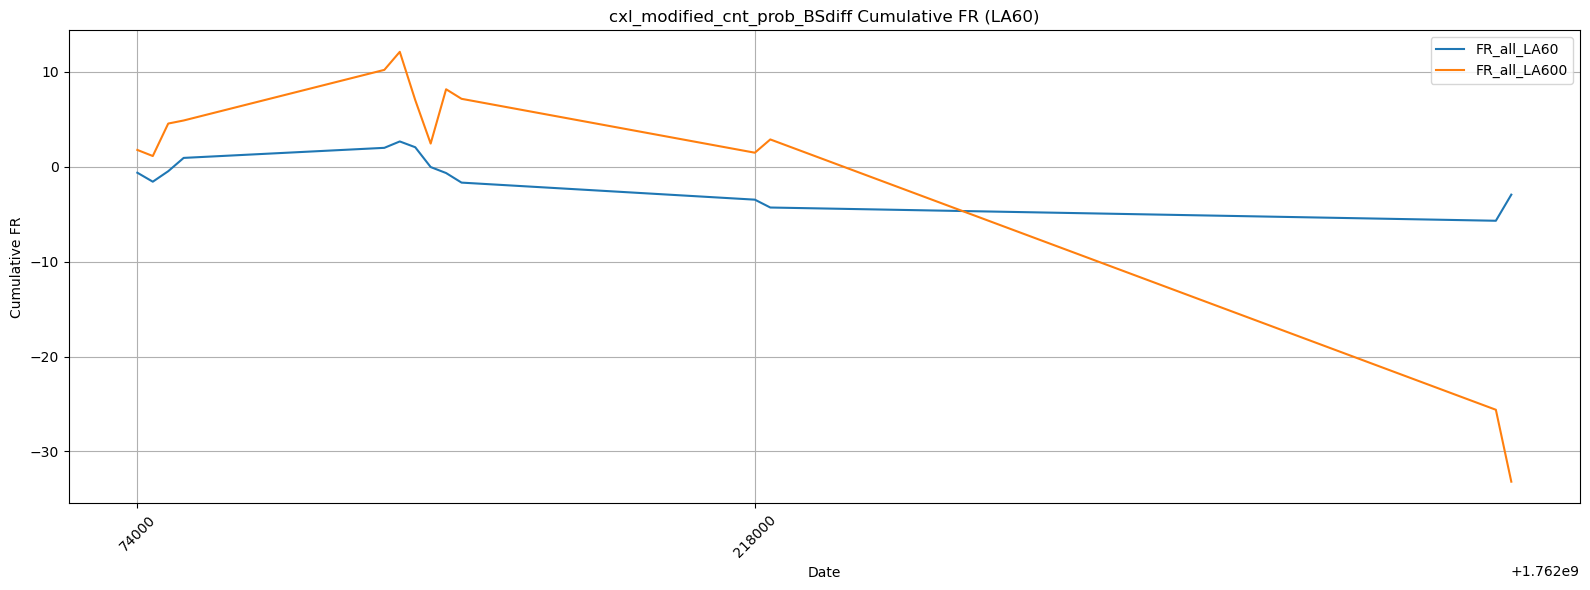

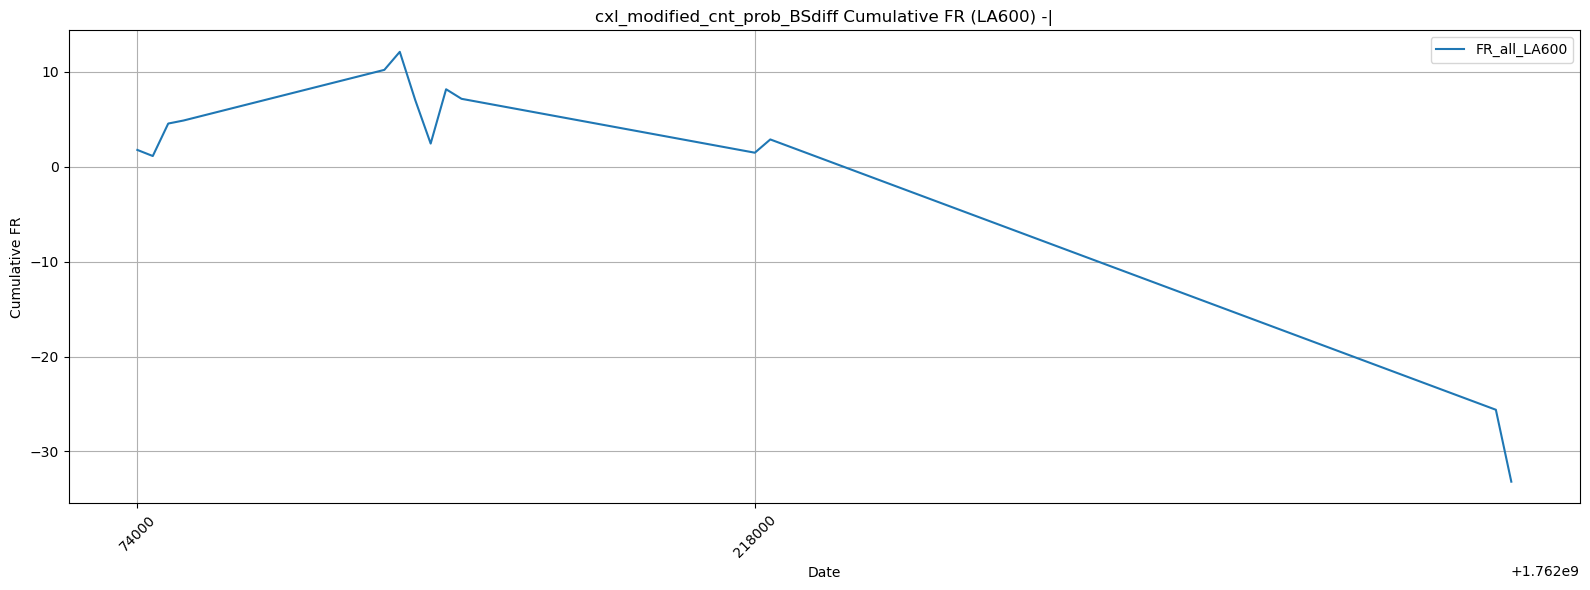

In [ ]:
def plot_cols(feat_col, df):
    # # 假设你已经有以下变量
    # feat_col = 'Around3s_AvgPrc_minusclose'
    ret_cols = ['LA60', 'LA600']

    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # 合并所有结果
    fr_df = pd.DataFrame(fr_all_results)

    # 计算 cumulative FR
    cumulative_fr_df = fr_df.cumsum()
    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'LA60' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'LA600' in col]

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (LA60)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (LA600) -|')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()
#     fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    
# 
plot_cols('BSdiff', results_df)

In [ ]:
# 挂单的筹码分布skew 时间做一个decay，偏度的变化量，（全量订单簿变化量的偏度， 最后一个时刻的偏度）

# 挂单的筹码：价格上涨：新增档位委买量+原档位净委买增加量+主买成交额； 被动卖出成交额+原档位净委卖减少量

# 新增档位委买量 / 被动卖出成交额；
# （新增档位委买量 + 净主买成交额） /  净被动卖出成交额

# （新增档位委买量 + 原档位净委买增加量） / （被动卖出成交额 + 原档位净委卖减少量）

# （新增档位委买量 + 原档位净委买增加量 + 净主买成交额） / （净被动卖出成交额 + 原档位净委卖减少量）

# 全量订单簿变化量

